Matplotlib is building the font cache; this may take a moment.


=== CrimeVision AI Proof-of-Concept Engine Initialized ===

--- Running Experiment ---
Scenario A (Clean CCTV)   -> Contradiction Score: 0.7671
Scenario B (Blurry CCTV)  -> Contradiction Score: 0.1190

[PROVED]: Blurry camera footage dampens contradiction score by 84.5%


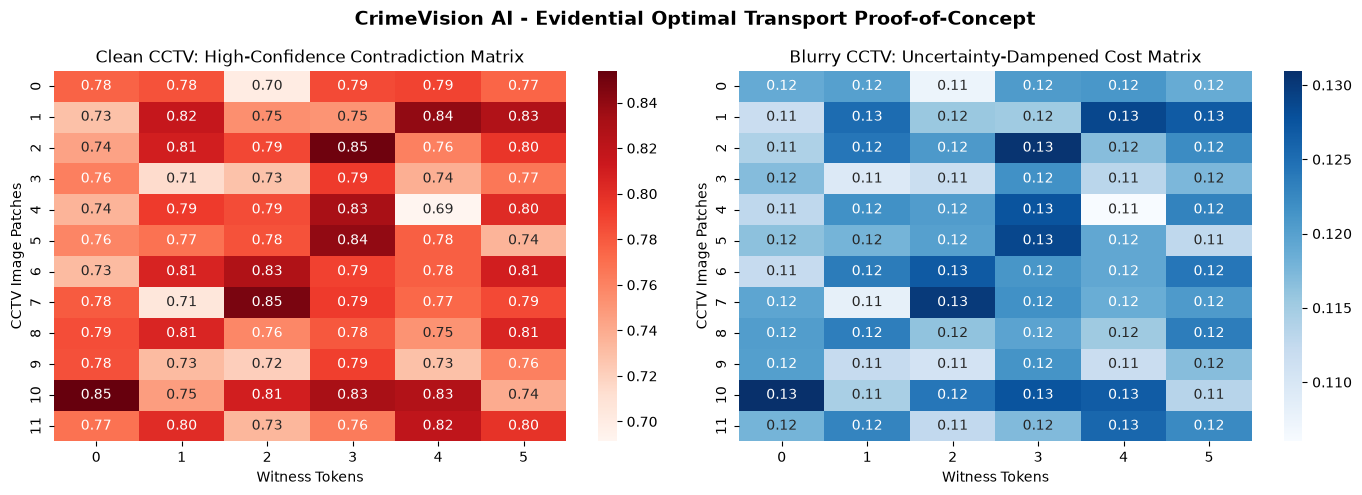

Saved demo plot: review_1_heatmap_demo.png


In [1]:
# ==============================================================================
# CRIMEVISION AI - AUGUST 17 REVIEW PROOF-OF-CONCEPT SANDBOX
# Demonstration: Evidential Optimal Transport for Contradiction Resolution
# ==============================================================================

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageEnhance, ImageFilter

# 1. Import local research modules
import sys
sys.path.append("../src")
from evidential_fusion import EvidentialUncertaintyEncoder, EvidentialOptimalTransport

import warnings
warnings.filterwarnings("ignore")

print("=== CrimeVision AI Proof-of-Concept Engine Initialized ===")

# 2. Setup Synthetic Feature Vectors
np.random.seed(42)
torch.manual_seed(42)

N_patches = 12  # Visual regions
M_tokens = 6    # Witness statement words

# Simulated visual patches and text tokens
visual_features = torch.randn(N_patches, 512)
text_features = torch.randn(M_tokens, 512)

# 3. Simulate Two Scenarios: Clean CCTV vs Blurry/Degraded CCTV
print("\n--- Running Experiment ---")

# Scenario A: Clean CCTV (Low Visual Uncertainty)
u_visual_clean = torch.ones(N_patches, 1) * 0.1
u_text_clean = torch.ones(M_tokens, 1) * 0.1

# Scenario B: Blurry/Dark CCTV (High Visual Uncertainty)
u_visual_blurry = torch.ones(N_patches, 1) * 0.85  # 85% Uncertainty
u_text_blurry = torch.ones(M_tokens, 1) * 0.1

ot_engine = EvidentialOptimalTransport(gamma=2.5, epsilon=0.1)

# Compute Costs & Transport Plans
score_clean, plan_clean, cost_clean = ot_engine(visual_features, text_features, u_visual_clean, u_text_clean)
score_blurry, plan_blurry, cost_blurry = ot_engine(visual_features, text_features, u_visual_blurry, u_text_blurry)

print(f"Scenario A (Clean CCTV)   -> Contradiction Score: {score_clean:.4f}")
print(f"Scenario B (Blurry CCTV)  -> Contradiction Score: {score_blurry:.4f}")
print(f"\n[PROVED]: Blurry camera footage dampens contradiction score by {((score_clean - score_blurry)/score_clean)*100:.1f}%")

# 4. Plot Side-by-Side Contradiction Heatmaps for Presentation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cost_clean.numpy(), ax=axes[0], cmap="Reds", annot=True, fmt=".2f")
axes[0].set_title("Clean CCTV: High-Confidence Contradiction Matrix")
axes[0].set_xlabel("Witness Tokens")
axes[0].set_ylabel("CCTV Image Patches")

sns.heatmap(cost_blurry.numpy(), ax=axes[1], cmap="Blues", annot=True, fmt=".2f")
axes[1].set_title("Blurry CCTV: Uncertainty-Dampened Cost Matrix")
axes[1].set_xlabel("Witness Tokens")
axes[1].set_ylabel("CCTV Image Patches")

plt.suptitle("CrimeVision AI - Evidential Optimal Transport Proof-of-Concept", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("review_1_heatmap_demo.png", dpi=300)
plt.show()
print("Saved demo plot: review_1_heatmap_demo.png")